# ForMap — Urban Thermal Simulation: Demo

**ForMap** generates thermal maps of entire cities by simulating heat exchange in urban street canyons (formed by roads and surrounding buildings).

The full system runs **244 000 canyons** across Milan on GPU in around a minute.
This notebook runs the **same physics** on **~1100 canyons** from Milan's Centrale district
(~2 min on CPU) to verify the phisics of the model with any hardware (no GPU or private code needed).

**What the model does:**
- Reads canyon geometry (width, height, orientation) from open-source OSM data
- Computes **solar irradiance geometry**, surfaces **shading** and **radiative view factors** analytically.
- Solves a **5-nodes ODE** system (road + 2 facades + canyon air + atmosphere) for one day of the year, considering **radiative** and **convective** thermal exchange between the nodes.
- Outputs `T_air_max` and `T_road_max` per each canyon.

**Scenario considered:**
Milan, 21 June (summer solstice), pre-dawn start at T = 20 °C everywhere.

-- **Run the cell below** to get the simulation ready. --

**PLEASE NOTE:**

To work correctly, cells must be run in order, starting from the first one!

In [1]:
!pip install plotly tqdm -q

import math, warnings
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import plotly.graph_objects as go
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
print('Ready.')

Ready.


## 1 - Solar Geometry Model

Solar altitude $\beta$ and irradiance $G$ at any hour are computed from the equation of time,
solar declination $\delta$, and hour angle $\omega$:

$$\sin\beta = \sin\phi\sin\delta + \cos\phi\cos\delta\cos\omega, \qquad G_\text{DNI} = 1367 \cdot 0.7^{1/\sin\beta} \;\text{(W m}^{-2}\text{)}$$

Milan: $\phi = 45.46°$N, June 21 ($n = 172$), UTC+1 (DST active).

Sun position moves during the day, varying the intensity of solar irradiance, creating moving shadows on different surfaces that change their temperature. The model considers this at every time step of 5 minutes, capturing the interaction between sunlight and buildings.

-- **The graph simulated below** shows the solar altitude and the corresponding intensity of solar irradiance throughout the day. --


In [2]:
def solar_position(clock_hour, day=172, lat=45.46, lon=9.19, lon_tz=15.0):
    """Return (altitude_deg, irradiance_W_m2, azimuth_deg) for a given local clock hour."""
    dst = 1 if 3 <= (day // 30 + 1) <= 10 else 0
    eot = 229.2 * (0.000075
                   + 0.001868 * math.cos(math.radians(360 * (day-1) / 365))
                   - 0.032077 * math.sin(math.radians(360 * (day-1) / 365))
                   - 0.014615 * math.cos(math.radians(720 * (day-1) / 365))
                   - 0.040849 * math.sin(math.radians(720 * (day-1) / 365)))
    decl        = 23.45 * math.sin(math.radians(360 * (284 + day) / 365))
    solar_time  = clock_hour + (4 * (lon_tz - lon) + eot) / 60 - dst
    hour_angle  = 15 * (solar_time - 12)
    sin_alt = max(-1.0, min(1.0,
                  math.sin(math.radians(lat)) * math.sin(math.radians(decl))
                  + math.cos(math.radians(lat)) * math.cos(math.radians(decl))
                  * math.cos(math.radians(hour_angle))))
    alt_rad = math.asin(sin_alt)
    irr     = (1367.0 * 0.7 ** (1.0 / (sin_alt + 1e-6))) if sin_alt > 0.0 else 0.0
    try:
        az_deg = math.degrees(math.asin(
            math.cos(math.radians(decl)) * math.sin(math.radians(hour_angle))
            / math.cos(alt_rad)))
    except (ValueError, ZeroDivisionError):
        az_deg = 0.0
    return math.degrees(alt_rad), irr, az_deg

hours = np.linspace(0, 24, 289)
sol   = [solar_position(h) for h in hours]
alts  = [s[0] for s in sol]
irrs  = [s[1] for s in sol]

fig = go.Figure()
fig.add_trace(go.Scatter(x=hours, y=irrs, mode='lines',
                         line=dict(color='orange', width=2.5), name='Irradiance (W m⁻²)'))
fig.add_trace(go.Scatter(x=hours, y=alts, mode='lines', yaxis='y2',
                         line=dict(color='steelblue', width=2, dash='dot'), name='Altitude (°)'))
fig.update_layout(
    title='Milan — Solar irradiance, 21 June',
    xaxis_title='Clock hour',
    yaxis=dict(title='Irradiance (W m⁻²)'),
    yaxis2=dict(title='Solar altitude (°)', overlaying='y', side='right'),
    legend=dict(x=0.01, y=0.99, xanchor='left', yanchor='top',
               bgcolor='rgba(255,255,255,0.8)'),
    template='plotly_white', height=370,
)
fig.show()

## 2 — Canyon Thermal Enclosure

Each street canyon is modelled as a closed **radiative + convective enclosure**. The thermal network topology — which nodes are coupled, how radiation and convection are parameterised, and how the atmosphere node is shared across canyons — is **proprietary**.

**ODE system:** $\mathbf{C}\,\dot{\mathbf{T}} = \mathbf{A}\,\mathbf{T} + \mathbf{b}(t)$, solved with scipy RK45.

- **Radiative coupling**: road, facades and sky exchange longwave radiation via a linearised network.
- **Convective coupling**: surfaces couple to canyon air, which vents to the atmosphere through the top opening and lateral ends.
- **Solar forcing** $\mathbf{b}(t)$: direct irradiance on each surface, computed from solar position and corrected for shading.

In [3]:
SIGMA = 5.67e-8
# Material properties: [road, facade_L, facade_R, air, atmosphere]
EPS   = np.array([0.90, 0.90, 0.90, 0.05, 0.90])
ALPHA = np.array([0.85, 0.70, 0.70, 0.00, 0.00])

# Surface heat capacities per unit area [J/(m²·K)]
# Road:   asphalt  2300 kg/m³ × 920 J/(kg·K) × 0.05 m active layer
# Facade: brick    1900 kg/m³ × 840 J/(kg·K) × 0.12 m active layer
_C_ROAD   = 2300 * 920  * 0.05   # 105 800 J/(m²·K)
_C_FACADE = 1900 * 840  * 0.12   # 191 520 J/(m²·K)


def canyon_view_factors(H, W):
    """2D cross-string view factors for an infinite symmetric canyon (r = H/W)."""
    r   = H / W
    Frf = (r + 1 - np.sqrt(r**2 + 1)) / 2    # road  → one facade
    Frs = np.sqrt(r**2 + 1) - r               # road  → sky
    Ffr = Frf / r                              # facade → road  (reciprocity)
    Fff = (np.sqrt(r**2 + 1) - 1) / r         # facade → opposite facade
    Ffs = 1.0 - Ffr - Fff                     # facade → sky
    F   = np.zeros((5, 5))
    F[0, 1] = F[0, 2] = Frf
    F[1, 0] = F[2, 0] = Ffr
    F[1, 2] = F[2, 1] = Fff
    F_sky = np.array([Frs, Ffs, Ffs, 0.0, 0.0])
    return F, F_sky


def build_matrices(H, W, L, orientation_rad=0.0,
                   T_ref=300.0, T_morning=293.0,
                   h_conv=5.0, h_atm=3.0):
    """
    Build A (5×5 W/K), b_sky (5, W), C (5, J/K), areas (5, m²).
    System ODE: C·dT/dt = A·T + b_solar(t) + b_sky
    """
    areas = np.array([
        W * L,          # road
        H * L,          # facade_L
        H * L,          # facade_R
        W * L,          # air (reference area = top opening)
        W * L * 1.5,    # atmosphere
    ])
    C = np.array([
        _C_ROAD   * areas[0],           # asphalt surface layer
        _C_FACADE * areas[1],           # brick facade surface layer
        _C_FACADE * areas[2],
        1.2 * 1005 * (H * W * L),      # air: ρ·Cp·V
        1.0e8 * L,                      # atmosphere: large reservoir
    ])

    F, F_sky = canyon_view_factors(H, W)

    # Radiative A matrix (Gebhart linearisation)
    n, R = 5, np.zeros((5, 5))
    for i in range(3):
        for j in range(3):
            if i != j and F[i, j] > 0:
                R[i, j] = (4 * SIGMA * T_ref**3) / (
                    (1 - EPS[i]) / (EPS[i] * areas[i])
                    + 1 / (F[i, j] * areas[i])
                    + (1 - EPS[j]) / (EPS[j] * areas[j])
                )
    A = np.diag(-R.sum(axis=1)) + R

    # Sky radiation: loss from A diagonal, constant gain in b_sky.
    # T_sky_eff = ε_sky^0.25 × T_morning (ε_sky = 0.80 → factor 0.9457):
    # clear-sky downwelling LW is cooler than ambient air (~15 K below T_morning).
    T_sky_eff = 0.9457 * T_morning
    b_sky = np.zeros(n)
    for i in range(3):
        G_sky = 4 * SIGMA * T_ref**3 * EPS[i] * F_sky[i] * areas[i]  # W/K
        A[i, i]  -= G_sky
        b_sky[i]  = G_sky * T_sky_eff

    # Convective A matrix
    G_r   = h_conv * areas[0]
    G_f1  = h_conv * areas[1]
    G_f2  = h_conv * areas[2]
    G_atm = h_atm  * (areas[3] + 2.0 * H * W)   # top + lateral openings
    Ac = np.zeros((n, n))
    Ac[0, 3] = G_r;   Ac[3, 0] = G_r;   Ac[0, 0] -= G_r
    Ac[1, 3] = G_f1;  Ac[3, 1] = G_f1;  Ac[1, 1] -= G_f1
    Ac[2, 3] = G_f2;  Ac[3, 2] = G_f2;  Ac[2, 2] -= G_f2
    Ac[3, 4] = G_atm; Ac[4, 3] = G_atm; Ac[4, 4] -= G_atm
    Ac[3, 3] = -(G_r + G_f1 + G_f2 + G_atm)
    A += Ac

    return A, b_sky, C, areas


# Sanity check: view factor rows should sum to 1 (internal + sky)
F_test, Fs_test = canyon_view_factors(H=10, W=10)
for name, row, fsky in zip(['road', 'facade_L', 'facade_R'], F_test[:3], Fs_test[:3]):
    print(f'{name:10s}: internal={row.sum():.3f}  sky={fsky:.3f}  total={row.sum()+fsky:.3f}')

# Surface time constants (τ = C/G_total) — sanity print
_A_test = 10 * 10  # 100 m² for H=W=10
_G_test = (4*SIGMA*300**3*0.9*(np.sqrt(2)-1) + 5) * _A_test
print(f'\nRoad τ (H=W=10, L=1): {_C_ROAD / (4*SIGMA*300**3*0.9*(np.sqrt(2)-1) + 5) / 3600:.1f} h  '
      f'(vs old hardcoded: {2e6 / (4*SIGMA*300**3*0.9*(np.sqrt(2)-1) + 5) / 3600:.0f} h)')

road      : internal=0.586  sky=0.414  total=1.000
facade_L  : internal=0.707  sky=0.293  total=1.000
facade_R  : internal=0.707  sky=0.293  total=1.000

Road τ (H=W=10, L=1): 4.0 h  (vs old hardcoded: 76 h)


## 3 — Importance of Canyon Geometry: Shallow vs. Deep Canyons

In a symmetric canyon with fixed width W and variable height H, a **shallow canyon (H/W = 0.5)** has a large surface exposed — it warms quickly and reaches higher peak temperatures.
In a **deep canyon (H/W = 2.0)**, the road is shaded for most of the day, and the small openings limit night-time radiative cooling — temperatures are more stable and peak temperatures are lower.

Both effects matter for urban heat: **peak heat** is driven by solar exposure; **heat persistence** is driven by canyon depth.

-- **Check in the graph below** that a shallow canyon reaches higher road and air temperature. --

In [4]:
def solar_input(t_sec, H, W, L, orientation_rad, areas):
    """Time-varying solar input vector b_solar [W], 5-node."""
    alt_deg, irr, az_deg = solar_position(t_sec / 3600.0)
    b = np.zeros(5)
    if irr <= 0 or alt_deg <= 0:
        return b
    alt_rad = math.radians(alt_deg)
    az_rad  = math.radians(az_deg)
    tan_alt = math.tan(alt_rad)

    # Road shading: |cos(az+orient)| is the cross-canyon perpendicular sun component.
    # az is astronomical (0=South); E-W canyon (orient=0) → |cos(0)|=1 at noon (max shadow).
    # N-S canyon (orient=π/2) → |cos(π/2)|=0 at noon (sun runs along canyon, no shadow).
    perp     = abs(math.cos(az_rad + orientation_rad))
    lit_road = max(0.0, 1.0 - (H / (W * tan_alt + 1e-6)) * perp)

    # Facade lit fraction: cross-canyon shadow height = W*tan(alt) / perp
    safe_perp = max(perp, 1e-4)
    lit_h     = min(H, W * tan_alt / safe_perp)
    fl_lit    = lit_h / H if H > 0 else 0.0

    # Solar direction toward sun; az is astronomical (0=South, +West) → negate horizontal components
    sd      = np.array([-math.sin(az_rad) * math.cos(alt_rad),
                        -math.cos(az_rad) * math.cos(alt_rad),
                         math.sin(alt_rad)])
    road_n  = np.array([0., 0., 1.])
    left_n  = np.array([ math.sin(orientation_rad), -math.cos(orientation_rad), 0.])
    right_n = -left_n

    b[0] = ALPHA[0] * areas[0] * irr * max(0., np.dot(road_n,  sd)) * lit_road
    b[1] = ALPHA[1] * areas[1] * irr * max(0., np.dot(left_n,  sd)) * fl_lit
    b[2] = ALPHA[2] * areas[2] * irr * max(0., np.dot(right_n, sd)) * fl_lit
    return b


def simulate_one(H, W, L=100.0, orientation_rad=0.0, T_morning=293.0,
                 T_ref=300.0, h_conv=5.0, h_atm=3.0, dt=300):
    """Simulate one canyon for 24 h; return (t_hours, T[n_steps, 5])."""
    A, b_sky, C, areas = build_matrices(H, W, L, orientation_rad, T_ref, T_morning, h_conv, h_atm)
    C_inv = 1.0 / C
    def rhs(t, T):
        return C_inv * (A @ T + b_sky + solar_input(t, H, W, L, orientation_rad, areas))
    T0     = np.full(5, T_morning)
    t_eval = np.arange(0.0, 86400.0 + dt, dt)
    sol    = solve_ivp(rhs, (0., 86400.), T0, method='RK45', t_eval=t_eval,
                       rtol=1e-4, atol=1e-3, max_step=dt)
    return sol.t / 3600.0, sol.y.T  # (n_steps, 5)


T_MORNING = 293.0   # 20 °C, Milan June pre-dawn

print('Simulating shallow canyon (H/W = 0.5)…')
t_sh, T_sh = simulate_one(H=10, W=20, T_morning=T_MORNING)
print('Simulating deep canyon   (H/W = 2.0)…')
t_dp, T_dp = simulate_one(H=40, W=20, T_morning=T_MORNING)

fig = go.Figure()
for label, t, T, dash in [('Shallow H/W=0.5', t_sh, T_sh, 'solid'),
                            ('Deep    H/W=2.0', t_dp, T_dp, 'dash')]:
    fig.add_trace(go.Scatter(x=t, y=T[:, 0]-273.15, name=f'T_road ({label})',
                             line=dict(color='#d62728', dash=dash)))
    fig.add_trace(go.Scatter(x=t, y=T[:, 3]-273.15, name=f'T_air ({label})',
                             line=dict(color='#1f77b4', dash=dash)))
fig.add_hline(y=T_MORNING-273.15, line_dash='dot', line_color='gray',
              annotation_text='T_morning')
fig.update_layout(title='Canyon thermal response: shallow vs deep (21 June, Milan)',
                  xaxis_title='Hour of day', yaxis_title='Temperature (°C)',
                  template='plotly_white', height=420)
fig.show()

for label, T, t in [('Shallow', T_sh, t_sh), ('Deep', T_dp, t_dp)]:
    print(f'{label:8s}  T_road_max={T[:,0].max()-273.15:.1f}°C  '
          f'T_air_max={T[:,3].max()-273.15:.1f}°C  '
          f'peak_hour={t[T[:,3].argmax()]:.1f}h')

Simulating shallow canyon (H/W = 0.5)…
Simulating deep canyon   (H/W = 2.0)…


Shallow   T_road_max=71.7°C  T_air_max=45.1°C  peak_hour=16.7h
Deep      T_road_max=47.0°C  T_air_max=30.7°C  peak_hour=17.8h


## 4 - Sample: Centrale District dataset

The model creates a 3D map of a city from open data and uses it for the simulation as described above. Using a GPU for parallelization, each canyon can be solved independently, allowing to create an output of a whole city like Milan in a matter of seconds. In this Demo a limited sample is proposed, to run the same simulation without the need of getting your GPU ready.

-- **Run the two cells below** to load the dataset and to run the simulation. --

In [5]:
# Load Centrale district dataset — 1096 canyons, pre-computed from OSM
URL = ('https://raw.githubusercontent.com/FedericoMattiuz/ForMap_Results'
       '/main/milan_centrale_1096.csv')
df = pd.read_csv(URL)
print(f'Loaded {len(df)} canyons')
df[['width', 'avg_height', 'aspect_ratio', 'road_length']].describe().round(1)

Loaded 1096 canyons


,width,avg_height,aspect_ratio,road_length
count,1096.0,1096.0,1096.0,1096.0
mean,15.0,17.4,1.2,44.9
std,0.6,4.6,0.3,59.9
min,6.0,2.0,0.1,1.3
25%,15.0,14.4,1.0,10.2
50%,15.0,17.0,1.1,15.8
75%,15.0,20.1,1.3,58.0
max,15.0,30.8,3.0,356.6


In [6]:
results = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Simulating canyons'):
    H      = float(row['avg_height'])
    W      = float(row['width'])
    L      = float(row.get('road_length', 100.0))
    orient = float(row.get('orientation_rad', 0.0))

    t_h, T = simulate_one(H, W, L, orient, T_morning=T_MORNING,
                          h_conv=5.0, h_atm=3.0)
    peak_idx = int(T[:, 3].argmax())
    results.append({
        'canyon_id':    row['canyon_id'],
        'lat':          row['lat'],
        'lon':          row['lon'],
        'aspect_ratio': row['aspect_ratio'],
        'T_road_max':   float(T[:, 0].max()) - 273.15,
        'T_air_max':    float(T[:, 3].max()) - 273.15,
        'peak_hour':    float(t_h[peak_idx]),
    })

res = pd.DataFrame(results)
print(f'\nMedian T_air_max  = {res.T_air_max.median():.1f} °C')
print(f'Median T_road_max = {res.T_road_max.median():.1f} °C')
print(f'Median peak_hour  = {res.peak_hour.median():.1f} h')
res[['T_road_max', 'T_air_max', 'peak_hour']].describe().round(1)

Simulating canyons:   0%|          | 0/1096 [00:00<?, ?it/s]


Median T_air_max  = 32.0 °C
Median T_road_max = 58.2 °C
Median peak_hour  = 16.1 h


,T_road_max,T_air_max,peak_hour
count,1096.0,1096.0,1096.0
mean,58.5,32.5,16.2
std,5.2,4.4,0.5
min,43.8,22.1,15.2
25%,55.3,29.5,15.9
50%,58.2,32.0,16.1
75%,61.3,35.3,16.5
max,78.7,52.0,17.8


##5 - Centrale district, Milan - Thermal Map Sample.

Each colored line segment represents the temperature in the corresponding canyon. Use the buttons to toggle between peak **air temperature** (T_air_max) and peak **road surface temperature** (T_road_max).

Two **road surface** hotspots (visible on T_road_max) emerge clearly: the **South-Eastern edge of Centrale station**, where the open area receives unobstructed solar radiation from the south; and a **diagonal road oriented East_West**, whose road surface is exposed for most of the day.

-- **Run the cell below** to visualize the map --

In [7]:
# Build canyon web: reconstruct segment endpoints from centroid + orientation + length
import math
import plotly.colors as pc

res_geo = res.merge(df[['canyon_id', 'orientation_rad', 'road_length']], on='canyon_id')

def canyon_endpoints(lat, lon, orientation_rad, road_length):
    """Return (lat1,lon1), (lat2,lon2) for a canyon centred at (lat,lon)."""
    half = road_length / 2.0
    lat_rad = math.radians(lat)
    dlat = (half * math.sin(orientation_rad)) / 111320.0
    dlon = (half * math.cos(orientation_rad)) / (111320.0 * math.cos(lat_rad))
    return (lat - dlat, lon - dlon), (lat + dlat, lon + dlon)

# Shared colour scale: air lower bound → road upper bound, so toggling
# immediately shows road is hotter (shifts into orange/yellow range)
vmin_shared = float(res_geo['T_air_max'].quantile(0.02))
vmax_shared = float(res_geo['T_road_max'].quantile(0.98))

def web_traces(col, vmin, vmax, colorscale='Inferno', n_bins=10):
    edges  = [vmin + i * (vmax - vmin) / n_bins for i in range(n_bins + 1)]
    colors = pc.sample_colorscale(colorscale, [i / (n_bins - 1) for i in range(n_bins)])
    traces = []
    for b in range(n_bins):
        lo, hi = edges[b], edges[b + 1]
        mask = (res_geo[col] >= lo) & (res_geo[col] <= hi)
        lats, lons = [], []
        for _, row in res_geo[mask].iterrows():
            (a, b2), (c, d) = canyon_endpoints(
                row['lat'], row['lon'], row['orientation_rad'], row['road_length'])
            lats += [a, c, None]; lons += [b2, d, None]
        mid = (lo + hi) / 2
        traces.append(go.Scattermap(
            lat=lats, lon=lons, mode='lines',
            line=dict(color=colors[b], width=2.5),
            name=f'{mid:.1f}°C', hoverinfo='skip', showlegend=False,
        ))
    # Colorbar dummy trace
    traces.append(go.Scattermap(
        lat=[None], lon=[None], mode='markers',
        marker=dict(colorscale=colorscale, cmin=vmin, cmax=vmax, color=[vmin],
                    size=0.1, colorbar=dict(title='Temperature (°C)', thickness=14, x=1.0)),
        showlegend=False,
    ))
    return traces

tr_air  = web_traces('T_air_max',  vmin=vmin_shared, vmax=vmax_shared)
tr_road = web_traces('T_road_max', vmin=vmin_shared, vmax=vmax_shared)
n = len(tr_air)   # n_bins + 1

vis_air  = [True]  * n + [False] * n
vis_road = [False] * n + [True]  * n

# Set initial visibility: T_air shown, T_road hidden
for t in tr_road:
    t.visible = False
fig = go.Figure(data=tr_air + tr_road)
fig.update_layout(
    map=dict(style='carto-darkmatter',
             center=dict(lat=res_geo['lat'].mean(), lon=res_geo['lon'].mean()),
             zoom=14),
    updatemenus=[dict(
        type='buttons', direction='right', x=0.5, y=1.08, xanchor='center',
        buttons=[
            dict(label='T_air_max',  method='update', args=[{'visible': vis_air}]),
            dict(label='T_road_max', method='update', args=[{'visible': vis_road}]),
        ],
    )],
    title='Centrale district, Milan — Peak temperatures (21 June) | ForMap MVP',
    height=580, margin=dict(r=60),
)
fig.show()


##6 - Canyon Shading Effect — T vs H/W

Peak temperatures **decrease** with canyon aspect ratio H/W: deeper canyons have taller buildings that shade the road and facades for most of the day. Less direct solar input means lower peak temperatures. The Pearson correlations (r) confirm the relationship is consistent across all canyons in the district.

This again confirms the importance of including building geometry in a thermal simulation.

--**Run the cell below** to visualize the temperature against aspect ratio H/W plot. --

In [8]:
# Canyon shading effect: temperatures vs H/W ratio
r_road = float(np.corrcoef(res['aspect_ratio'], res['T_road_max'])[0, 1])
r_air  = float(np.corrcoef(res['aspect_ratio'], res['T_air_max'])[0, 1])

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=res['aspect_ratio'], y=res['T_road_max'],
    mode='markers', name='T_road_max',
    marker=dict(color=res['T_road_max'], colorscale='Inferno',
                size=6, opacity=0.55,
                showscale=True, colorbar=dict(title='T_road_max (°C)')),
    hovertemplate='H/W=%{x:.2f}<br>T_road_max=%{y:.1f}°C<extra></extra>',
))
fig.add_trace(go.Scatter(
    x=res['aspect_ratio'], y=res['T_air_max'],
    mode='markers', name='T_air_max',
    marker=dict(color='#1f77b4', size=5, opacity=0.45),
    hovertemplate='H/W=%{x:.2f}<br>T_air_max=%{y:.1f}°C<extra></extra>',
))
fig.add_annotation(
    x=0.97, y=0.97, xref='paper', yref='paper', showarrow=False,
    text=f'r(road) = {r_road:.2f}<br>r(air) = {r_air:.2f}',
    align='right', bgcolor='white', bordercolor='lightgray',
)
fig.update_layout(
    title='Canyon shading effect: peak temperatures vs aspect ratio H/W',
    xaxis_title='Aspect ratio H/W',
    yaxis_title='Peak temperature (°C)',
    legend=dict(x=0.01, y=0.99, xanchor='left', yanchor='top',
               bgcolor='rgba(255,255,255,0.8)'),
    template='plotly_white', height=480,
)
fig.show()

## 7 - Scale-up: full Milan (244 000 canyons)

The full ForMap run executes the same physics on all **244 000 street canyons** in Milan using a custom JAX GPU solver with **operator splitting** for the shared atmosphere:

- Each 5-min time step: all 244 k canyon ODEs solved in a single GPU call.
- Atmosphere temperature updated globally between steps (city-wide UHI feedback).
- **Diurnal background**: atmosphere follows a smooth daily curve (+8 °C peak at 2 pm), so all canyons warm through the day — including shaded and short ones.

Full-city results (June 21, T_morning = 24.1 °C — milan_2022 scenario, diurnal atmosphere):

| Metric | Mean | Median | p90 | Max |
|---|---|---|---|---|
| T_air_max | 33.1 °C | 33.4 °C | 35.8 °C | 42.7 °C |
| T_road_max | 61.0 °C | 62.3 °C | 69.8 °C | 85.1 °C |
| Peak hour | — | 16.1 h | — | — |
| Simulation time | **46.7 s** | — | — | 5 231 canyons per second |

### ForMap capabilities

- **Full-city thermal maps** — 244 000 canyons of Milan simulated in 47 seconds on a single GPU; same pipeline **runs on any city** with OpenStreetMap coverage.
- **Open data only** — all inputs come from OpenStreetMap and Copernicus; no field sensors, no proprietary datasets.
- **Physics-based** — 5-node radiative + convective ODE per canyon; solar geometry, shading and view factors computed analytically from the building geometry.
- **Street-level resolution** — adaptive results at individual canyon granularity, not averages depending on data resolution.
- **Climate scenario analysis** — swap any historical or projected morning temperature (ERA5 / CMIP6 projections) to compare years or emissions pathways.
- **Actionable output** — maps which streets exceed critical temperature thresholds, supporting urban planners, infrastructure designers, and emergency response.

Interactive full-city outputs are in the [formap-results repository](https://github.com/FedericoMattiuz/ForMap_Results):
- [`map_interactive.html`](https://federicomattiuz.github.io/ForMap_Results/map_interactive.html) — all 244 k canyons coloured by T_air_max.
- [`temporal_slider.html`](https://federicomattiuz.github.io/ForMap_Results/temporal_slider.html) — animated hourly snapshots.
- [`canyon_effect.html`](https://federicomattiuz.github.io/ForMap_Results/canyon_effect.html) — T_air_max vs H/W for all canyons.

## 7b — ERA5 Validation: ForMap vs Observed Air Temperature

To validate the model, the full-city simulation was run for **21 June 2022** (T_morning = 24.1 °C, ERA5 pre-dawn) and compared against ERA5 hourly temperatures for Milan.

Key results:
- **00 h**: ForMap = ERA5 = 24.1 °C — exact match at start ✓
- **16 h**: ForMap = 33.3 °C vs ERA5 = 33.3 °C — **dead match at peak** ✓
- **17 h**: ForMap exceeds ERA5 by +1.9 °C — **correct UHI signature** (city retains heat after solar peak) ✓
- **Morning cold bias (01–13 h)**: ForMap runs 2–7 °C below ERA5. (Thermal inertia has to be built during the first hours of simulation. This can be modelled in v1.0+).

The chart below shows the ForMap median T_air (with p10–p90 band across all 244 k canyons) against the ERA5 reference.

In [9]:
from IPython.display import IFrame
IFrame('https://federicomattiuz.github.io/ForMap_Results/era5_comparison.html',
       width='100%', height=500)

## 8 - Climate scenarios: 2024 baseline vs 2022 heatwave

Loading historical temperatures from ERA5 analysis, ForMap can run the full city simulation for any year. This allows to easily compare past scenarios and make predictions for the immediate future.

The two maps simulated by the code below show Milan on the same summer day under two different conditions — **normal weather and during a heatwave**.

| Scenario | T_morning | Mean T_air_max | Canyons > 30 °C |
|---|---|---|---|
| Milan 2024 | 21.3 °C | 30.6 °C | 64.5 % |
| **Milan 2022 (heatwave)** | **24.6 °C** | **33.5 °C** | **91.0 %** |

> **+26.5 percentage points more canyons exceed 30 °C** during the heatwave (64.5 % → 91.0 %) — the same streets become a public health risk.

Adapting to the Urban Heat Island (UHI) effect requires a comprehensive view of how the temperature evolves inside a city. ForMap can **identify hotspots**, **analyze heatwaves**, and in the future **predict extreme events** and **help reduce the impact** that high temperatures have on everything that is part of a city. Not just in Milan, but wherever Open Data are available.

-- **Run the code below** to simulate the maps side by side. --

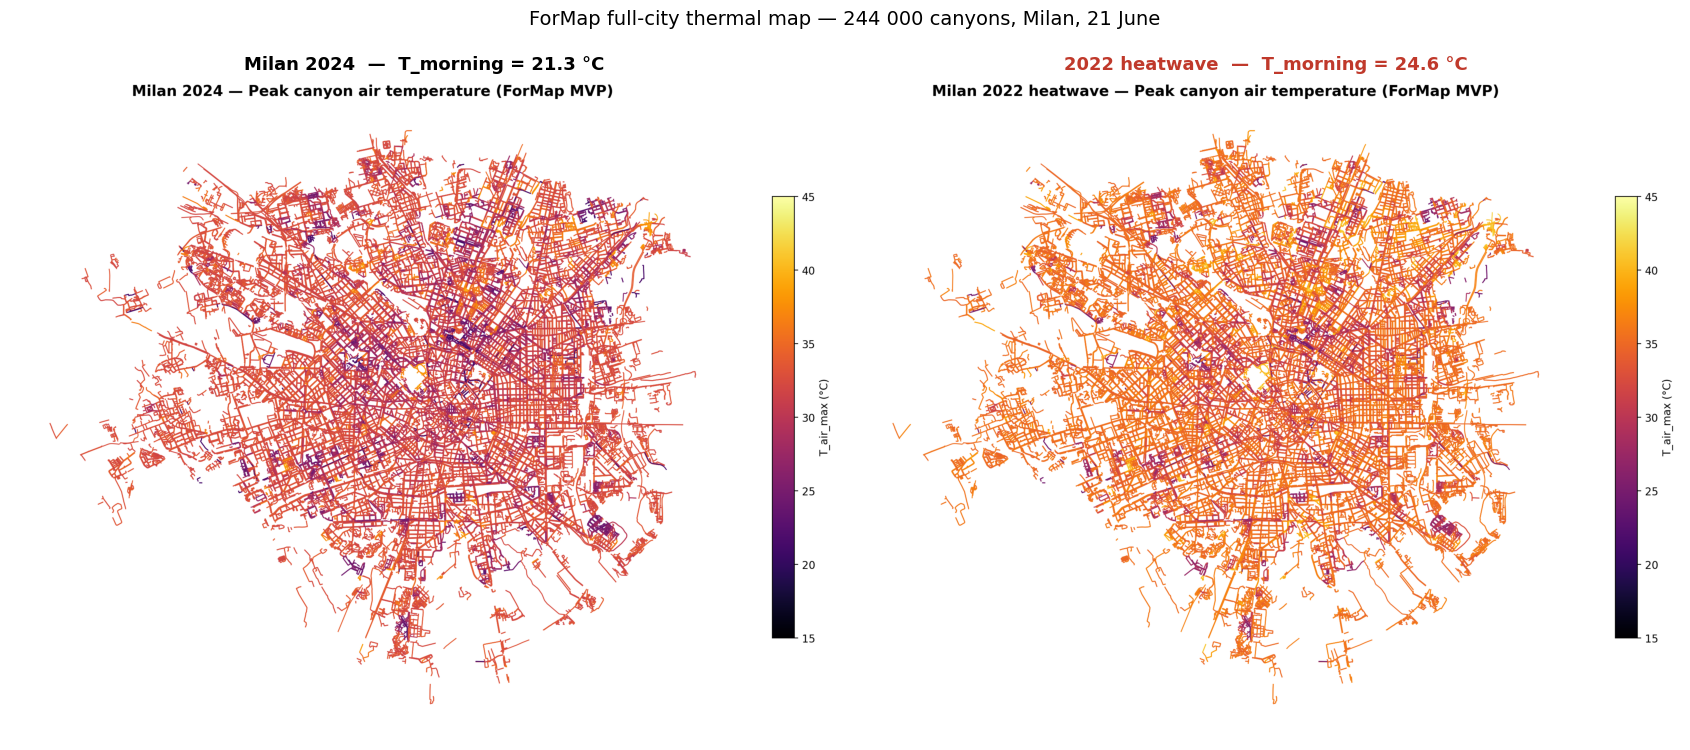

Same legend scale. Purple/violet = cooler streets. Orange/red = hottest streets.


In [10]:
# Side-by-side thermal maps: 2024 baseline vs 2022 heatwave
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

BASE = ('https://raw.githubusercontent.com/FedericoMattiuz/ForMap_Results'
        '/main/static_maps/')

def load_img(name):
    r = requests.get(BASE + name, timeout=30)
    r.raise_for_status()
    return Image.open(BytesIO(r.content))

img_2024 = load_img('milan_2024.png')
img_hw   = load_img('milan_2022_heatwave.png')

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
axes[0].imshow(img_2024)
axes[0].set_title('Milan 2024  —  T_morning = 21.3 °C', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_hw)
axes[1].set_title('2022 heatwave  —  T_morning = 24.6 °C', fontsize=13,
                  fontweight='bold', color='#c0392b')
axes[1].axis('off')

fig.suptitle('ForMap full-city thermal map — 244 000 canyons, Milan, 21 June',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("Same legend scale. Purple/violet = cooler streets. Orange/red = hottest streets.")

---

## 9 - Where this is going

This notebook demonstrates that ForMap can already answer *where* a city overheats and *why* — resolved to individual street geometries, from open data, in seconds, per city.

ForMap is the thermal mapping tool of **Forban**, a personal project aiming to found an innovative startup dedicated to develop a new concept of urban green infrastructures for climate adaptation.

The simulation is designed as the physics engine **for a broader platform**, contributing to:

- Compute **operational parameters** for the maintenance of existing urban green areas — irrigation demand, maintenance schedules, intervention performance — starting from the physics of each specific street.

- Evaluate the **thermal impact of urban green infrastructures** — green roofs, cool pavements, tree covers, and novel infrastructure concepts currently in development — analytically, before anything is built.

- Help **Urban Planners**, **Municipalities** and **Consultancy Partners** from every part of Italy, Europe, and the rest of the World, to properly adapt to increasing urban temperatures. Not just by calculating a thermal map - but using it as a **physical baseline** to compute and provide **concrete operational parameters** such as **cost reductions**, **ROI**, and **climatic/environmental performance**.

The core thesis: the parametric sensitivity you have seen here (how geometry and surface properties drive temperature) is exactly what is needed to design effective urban interventions and assess them quantitatively. The platform is built to take that step — from heat diagnosis to intervention design, at city scale.

---

ForMap MVP — thermal mapping of cities from open-source geospatial data.  
Physics: 5-node radiative + convective enclosure, linearised network, JAX GPU solver (operator splitting).  
Data: OpenStreetMap + Copernicus (LOD1).  
Part of **Forban** — urban green infrastructure for climate adaptation.

*Contact: federico.mattiuz00@gmail.com*